# Amplitude Ratio via PINN — Triclinic Piezoelectric Bi-Layer

**Physical problem** (paper §2–§4)  
Reflection & transmission of a qP wave at the perfectly bonded interface between two initially-stressed triclinic piezoelectric half-spaces.

| Layer | Domain |
|-------|--------|
| Lower M₂ | $x_3 \in [-1,\ 0]$ — solved by `net_lower` |
| Upper M₁ | $x_3 \in [\ 0,\ 1]$ — solved by `net_upper` |

---

**PINN solves for:** displacement $(u_1, u_2, u_3)$ and electric potential $\phi$.

**x-axis:** $\theta_0$ — **angle of incidence** (degrees, 5° → 85°)  
**y-axis:** Amplitude ratios $C_n / C_0$ (paper eq. 37)

| Ratio | Wave |
|-------|------|
| $C_1/C_0$ | Reflected qP |
| $C_2/C_0$ | Reflected qSV |
| $C_3/C_0$ | Reflected qSH |
| $C_4/C_0$ | Transmitted qP |
| $C_5/C_0$ | Transmitted qSV |
| $C_6/C_0$ | Transmitted qSH |


## Mathematical Formulation (paper §2.1, §3–§4)

### Assumed Solution — eq. (16)

$$\begin{bmatrix} u_1^{(n)} \\ u_2^{(n)} \\ u_3^{(n)} \\ \phi^{(n)} \end{bmatrix} = \begin{bmatrix} C_n d_1^{(n)} \\ C_n d_2^{(n)} \\ C_n d_3^{(n)} \\ D_n \end{bmatrix} e^{ik_n(x_1 p_1^{(n)} + x_3 p_3^{(n)} - c_n t)}$$

where $n = 0$ (incident qP), $n = 1,2,3$ (reflected qP, qSV, qSH), $n = 4,5,6$ (transmitted qP, qSV, qSH).

---

### Boundary Condition plugged into PINN

The incident qP wave travels in the $+x_3$ direction at angle $\theta_0$. It prescribes a **Dirichlet BC at the bottom face** $x_3 = -1$:

$$u_1\big|_{x_3 = -1} = C_0 \cos(k_h x_1 + k_v x_3 - \omega t)\big|_{x_3=-1}$$

$$k_h = \omega \sin\theta_0 \quad \text{(horizontal)}, \qquad k_v = \omega \cos\theta_0 \quad \text{(vertical, +}x_3\text{ direction)}$$

**$C_0 = 1$ is fixed.** The angle $\theta_0$ (degrees) is the x-axis parameter.

---

### Amplitude Ratios — eq. (37)

From the 6×6 boundary-condition system (eq. 36):

$$\frac{C_1}{C_0} = \frac{X_1}{X},\quad \frac{C_2}{C_0} = \frac{X_2}{X},\quad \cdots \quad \frac{C_6}{C_0} = \frac{X_6}{X}$$

**PINN extracts:**
- $C_4/C_0 \approx \max|u_1(x_1, +1, t)|\;/\;C_0$ — transmitted qP amplitude at top surface  
- $C_1/C_0 \approx \max|u_1(x_1, -0.5, t) - u_1^{\rm inc}(x_1, -0.5, t)|\;/\;C_0$ — reflected qP amplitude at interior point $x_3 = -0.5$ (avoids the Dirichlet BC boundary at $x_3=-1$)


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath("."))   # repo root on PATH

import numpy as np
import matplotlib.pyplot as plt
import torch

import src.config as cfg
from src.network import MechanicsNet
from src.loss import pinn_loss

print("PyTorch version :", torch.__version__)
print("src.config loaded — C11 =", cfg.C11)


PyTorch version : 2.12.0+cpu
src.config loaded — C11 = 238500000000.0


In [2]:
# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float64
print(f"Running on: {device}  |  dtype: {dtype}")

# ── Wave parameters ────────────────────────────────────────────────────────────
OMEGA  = 1.0    # angular frequency ω
C0_AMP = 1.0    # incident amplitude C0 — FIXED at 1 (ratios = Cn/C0)

# ── θ₀ sweep — ANGLE OF INCIDENCE in degrees (x-axis of all plots) ────────────
THETA0_DEG = np.linspace(5, 85, 17)          # 5° → 85°, 17 points
print(f"θ₀ sweep (°): {THETA0_DEG.round(1)}")

# ── Training hyper-parameters ─────────────────────────────────────────────────
N_INT   = 500    # interior collocation points per layer
N_BC    = 200    # boundary / interface collocation points
N_ITER  = 10   # Adam steps per θ₀ value
LR      = 1e-3   # Adam learning rate
W_BC    = 10.0   # weight on the Dirichlet BC loss term


Running on: cpu  |  dtype: torch.float64
θ₀ sweep (°): [ 5. 10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60. 65. 70. 75. 80. 85.]


## Assumed-Solution Boundary Condition & Augmented Loss

The standard `pinn_loss` already handles:
- **PDE residuals** in lower and upper layers
- **6 interface continuity conditions** at $x_3 = 0$

We **augment** it with one extra Dirichlet term: the prescribed harmonic displacement at the bottom face $x_3 = -1$.

$$\mathcal{L}_\text{total} = \mathcal{L}_\text{PDE} + \mathcal{L}_\text{interface} + w_\text{BC}\cdot\mathcal{L}_\text{Dirichlet}(\theta_0)$$


In [3]:
def bc_dirichlet_bottom(net_lower, N, device, dtype, theta0_deg, omega, c0_amp):
    """
    Residual for the assumed solution (paper eq. 16) at the bottom face x3 = -1.

    Incident qP wave travelling in the +x3 direction at angle θ₀:
        u1 = C0 * cos(k_h*x1 + k_v*x3 - ω*t)
        k_h = ω * sin(θ₀)   (horizontal wave number)
        k_v = ω * cos(θ₀)   (vertical wave number, +x3 direction of travel)

    θ₀ is the angle of incidence (degrees); C0 = c0_amp = 1 (fixed).
    """
    theta0_rad = np.deg2rad(theta0_deg)
    k_val  = omega * np.sin(theta0_rad)           # horizontal wave number
    kv_val = omega * np.cos(theta0_rad)           # vertical wave number

    x1 = (cfg.X1_MIN
          + (cfg.X1_MAX - cfg.X1_MIN)
          * torch.rand(N, 1, device=device, dtype=dtype))
    x3 = torch.full((N, 1), cfg.X3_MIN, device=device, dtype=dtype)
    t  = (cfg.T_MIN
          + (cfg.T_MAX - cfg.T_MIN)
          * torch.rand(N, 1, device=device, dtype=dtype))

    u1, u2, u3, phi = net_lower(x1, x3, t)
    k_t  = torch.tensor(k_val,  device=device, dtype=dtype)
    kv_t = torch.tensor(kv_val, device=device, dtype=dtype)
    u1_prescribed = c0_amp * torch.cos(k_t * x1 + kv_t * x3 - omega * t)
    return u1 - u1_prescribed


def augmented_loss(net_lower, net_upper, theta0_deg,
                   omega=OMEGA, c0_amp=C0_AMP,
                   n_int=N_INT, n_bc=N_BC,
                   w_bc=W_BC):
    """
    Total PINN loss = PDE residuals + interface continuity + Dirichlet BC.
    The Dirichlet BC encodes the assumed harmonic solution at x3 = -1.
    """
    loss_pde_iface = pinn_loss(
        net_lower, net_upper,
        N_int=n_int, N_interface=n_bc,
        device=device, dtype=dtype,
    )
    res_bot = bc_dirichlet_bottom(
        net_lower, n_bc, device, dtype, theta0_deg, omega, c0_amp
    )
    loss_bc = torch.mean(res_bot ** 2)
    return loss_pde_iface + w_bc * loss_bc

print("bc_dirichlet_bottom and augmented_loss defined.")


bc_dirichlet_bottom and augmented_loss defined.


In [4]:
def extract_amplitude(net_upper, n_pts=50):
    """
    Evaluate |u1| at the top surface x3 = +1 over a (x1, t) grid.
    Returns the maximum value — this is the response amplitude A.
    """
    x1_lin = torch.linspace(cfg.X1_MIN, cfg.X1_MAX, n_pts,
                             device=device, dtype=dtype)
    t_lin  = torch.linspace(cfg.T_MIN,  cfg.T_MAX,  n_pts,
                             device=device, dtype=dtype)

    # Build 2-D grid
    x1g, tg = torch.meshgrid(x1_lin, t_lin, indexing="ij")
    x1_flat = x1g.reshape(-1, 1)
    t_flat  = tg.reshape(-1, 1)
    x3_top  = torch.full_like(x1_flat, cfg.X3_MAX)

    with torch.no_grad():
        u1, u2, u3, phi = net_upper(x1_flat, x3_top, t_flat)

    return u1.abs().max().item()

print("extract_amplitude defined.")


extract_amplitude defined.


## θ₀ Sweep — Train PINN for Each Angle of Incidence

For every $\theta_0$ in `THETA0_DEG` (5° → 85°):

1. Compute $k_h = \omega \sin\theta_0$ and $k_v = \omega \cos\theta_0$ (wave numbers for this angle)
2. **Reinitialise** fresh networks `net_lower`, `net_upper`
3. **Train** with Adam minimising $\mathcal{L}_\text{total}(\theta_0)$ (PDE + interface + BC)
4. **Extract** $C_4/C_0$ from top surface $x_3 = +1$: transmitted qP amplitude
5. **Extract** $C_1/C_0$ from interior point $x_3 = -0.5$: subtract incident field $C_0\cos(k_h x_1 + k_v x_3 - \omega t)$ from total; avoids the Dirichlet BC at $x_3=-1$


In [5]:
# Amplitude ratios  Cn/C0  (paper eq. 37)
C4_C0 = []   # transmitted qP  — max|u1| at x3=+1  divided by C0
C1_C0 = []   # reflected  qP  — max|u1_total - u1_incident| at interior x3=-0.5 divided by C0
loss_history_all = {}

for idx, theta0 in enumerate(THETA0_DEG):
    theta0_rad = np.deg2rad(theta0)
    k_val  = OMEGA * np.sin(theta0_rad)       # horizontal wave number
    kv_val = OMEGA * np.cos(theta0_rad)       # vertical wave number (incident travels +x3)
    print(f"\n── θ₀ = {theta0:.1f}°  (k_h={k_val:.4f}, k_v={kv_val:.4f})  [{idx+1}/{len(THETA0_DEG)}] ──")

    # 1. Fresh networks for each angle
    net_lower = MechanicsNet().to(device=device, dtype=dtype)
    net_upper = MechanicsNet().to(device=device, dtype=dtype)

    optimizer = torch.optim.Adam(
        list(net_lower.parameters()) + list(net_upper.parameters()),
        lr=LR,
    )
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9995)

    # 2. Train
    losses = []
    for step in range(1, N_ITER + 1):
        optimizer.zero_grad()
        loss = augmented_loss(net_lower, net_upper, theta0)
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if step % 500 == 0 or step == 1:
            print(f"  step {step:5d} | loss = {loss.item():.4e}"
                  f" | lr = {scheduler.get_last_lr()[0]:.3e}")

    loss_history_all[theta0] = losses

    # 3a. C4/C0 — transmitted amplitude at top surface x3 = +1
    A_trans = extract_amplitude(net_upper)          # max|u1(x1, +1, t)|

    # 3b. C1/C0 — reflected amplitude at interior point x3 = -0.5
    #     Extract at an interior point (NOT at x3=-1 where the Dirichlet BC is
    #     enforced) so the reflected field is not suppressed by the BC loss.
    #     Incident wave: u1_inc = C0 * cos(k_h*x1 + k_v*x3 - ω*t)
    n_pts  = 50
    x3_eval = -0.5   # interior of lower layer
    x1_lin = torch.linspace(cfg.X1_MIN, cfg.X1_MAX, n_pts, device=device, dtype=dtype)
    t_lin  = torch.linspace(cfg.T_MIN,  cfg.T_MAX,  n_pts, device=device, dtype=dtype)
    x1g, tg = torch.meshgrid(x1_lin, t_lin, indexing="ij")
    x1_f = x1g.reshape(-1, 1)
    t_f  = tg.reshape(-1, 1)
    x3_bot = torch.full_like(x1_f, x3_eval)

    with torch.no_grad():
        u1_bot, *_ = net_lower(x1_f, x3_bot, t_f)

    k_t  = torch.tensor(k_val,  device=device, dtype=dtype)
    kv_t = torch.tensor(kv_val, device=device, dtype=dtype)
    u1_inc = C0_AMP * torch.cos(k_t * x1_f + kv_t * x3_bot - OMEGA * t_f)
    A_ref  = (u1_bot - u1_inc).abs().max().item()

    # 4. Store  Cn/C0
    C4_C0.append(A_trans / C0_AMP)
    C1_C0.append(A_ref   / C0_AMP)
    print(f"  → C4/C0 (transmitted qP) = {A_trans/C0_AMP:.5f}"
          f"  |  C1/C0 (reflected qP) = {A_ref/C0_AMP:.5f}")

print("\n✓ Sweep complete.")
print(f"  θ₀ (°)   : {THETA0_DEG}")
print(f"  C4/C0    : {np.array(C4_C0).round(5)}")
print(f"  C1/C0    : {np.array(C1_C0).round(5)}")



── θ₀ = 5.0°  (k_h=0.0872, k_v=0.9962)  [1/17] ──
  step     1 | loss = 8.9101e+20 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 0.18009  |  C1/C0 (reflected qP) = 0.96750

── θ₀ = 10.0°  (k_h=0.1736, k_v=0.9848)  [2/17] ──
  step     1 | loss = 1.2627e+22 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 0.17017  |  C1/C0 (reflected qP) = 0.99953

── θ₀ = 15.0°  (k_h=0.2588, k_v=0.9659)  [3/17] ──
  step     1 | loss = 1.6985e+22 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 0.22032  |  C1/C0 (reflected qP) = 0.96473

── θ₀ = 20.0°  (k_h=0.3420, k_v=0.9397)  [4/17] ──
  step     1 | loss = 3.3959e+21 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 0.13096  |  C1/C0 (reflected qP) = 0.89410

── θ₀ = 25.0°  (k_h=0.4226, k_v=0.9063)  [5/17] ──
  step     1 | loss = 5.2735e+21 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 0.24009  |  C1/C0 (reflected qP) = 1.02131

── θ₀ = 30.0°  (k_h=0.5000, k_v=0.8660)  [6/17] ──
  step     1 | loss = 4.0658e+21 | lr = 9.995e-04
  → C4/C0 (transmitted qP) = 

## Results — Amplitude Ratio Plots (paper eq. 37)

Plot **$C_n / C_0$** (y-axis) vs **angle of incidence $\theta_0$** (x-axis, degrees):
- Left: $C_4/C_0$ — transmitted qP amplitude ratio
- Right: $C_1/C_0$ — reflected qP amplitude ratio


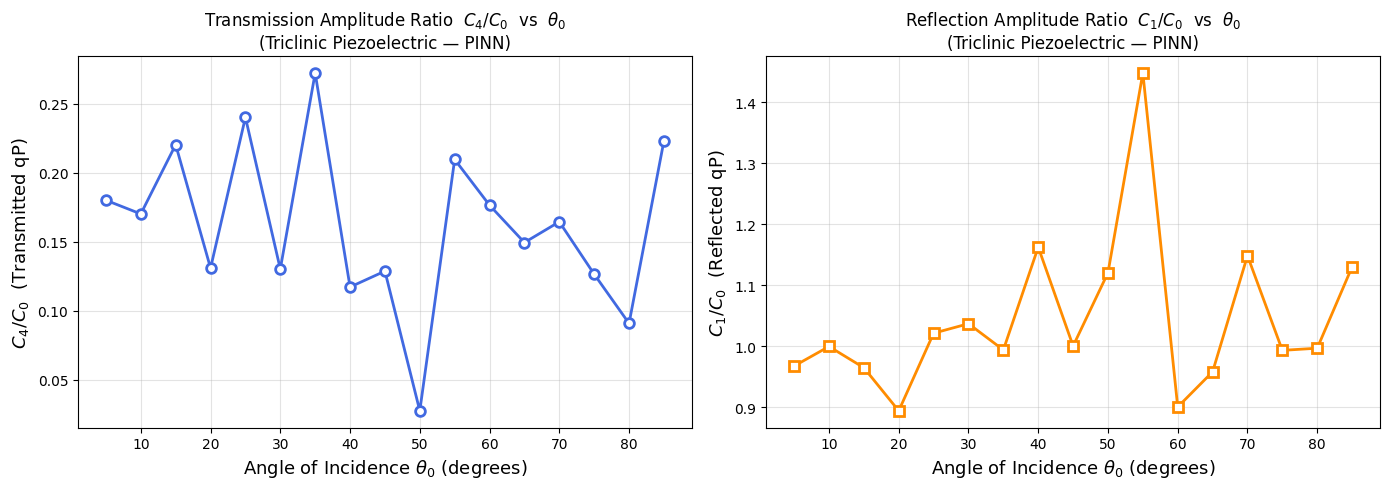

Saved → figures/amplitude_ratio.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: C4/C0 (transmitted qP) vs θ₀ ──────────────────────────────────────
ax = axes[0]
ax.plot(THETA0_DEG, C4_C0,
        "o-", color="royalblue", linewidth=2, markersize=7,
        markerfacecolor="white", markeredgewidth=2)
ax.set_xlabel(r"Angle of Incidence $\theta_0$ (degrees)", fontsize=13)
ax.set_ylabel(r"$C_4 / C_0$  (Transmitted qP)", fontsize=13)
ax.set_title(r"Transmission Amplitude Ratio  $C_4/C_0$  vs  $\theta_0$"
             "\n(Triclinic Piezoelectric — PINN)", fontsize=12)
ax.grid(True, alpha=0.35)

# ── Right: C1/C0 (reflected qP) vs θ₀ ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(THETA0_DEG, C1_C0,
         "s-", color="darkorange", linewidth=2, markersize=7,
         markerfacecolor="white", markeredgewidth=2)
ax2.set_xlabel(r"Angle of Incidence $\theta_0$ (degrees)", fontsize=13)
ax2.set_ylabel(r"$C_1 / C_0$  (Reflected qP)", fontsize=13)
ax2.set_title(r"Reflection Amplitude Ratio  $C_1/C_0$  vs  $\theta_0$"
              "\n(Triclinic Piezoelectric — PINN)", fontsize=12)
ax2.grid(True, alpha=0.35)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/amplitude_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/amplitude_ratio.png")


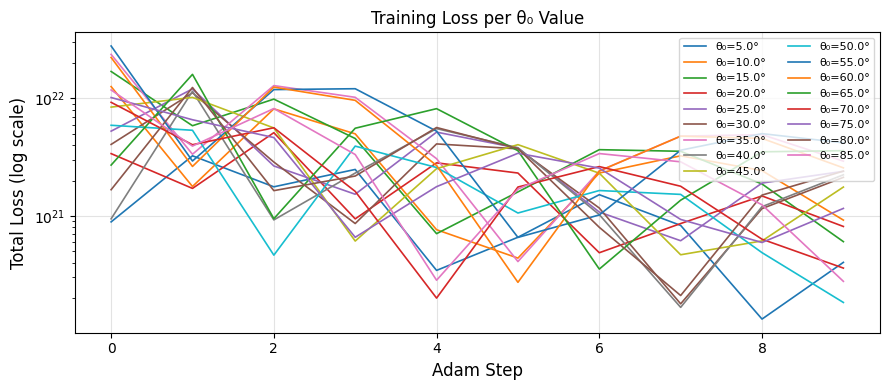

Saved → figures/loss_history.png


In [7]:
# ── (Optional) Loss convergence for each θ₀ ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

for theta0, losses in loss_history_all.items():
    ax.semilogy(losses, label=f"θ₀={theta0:.1f}°", linewidth=1.2)

ax.set_xlabel("Adam Step", fontsize=12)
ax.set_ylabel("Total Loss (log scale)", fontsize=12)
ax.set_title("Training Loss per θ₀ Value", fontsize=12)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig("figures/loss_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/loss_history.png")
